# Part 4 — Bias Mitigation

Three complementary mitigation techniques are applied and compared:

| # | Technique | Mechanism |
|---|-----------|----------|
| 1 | **Reweighing** (AIF360) | Assign higher weight to under-represented (black) samples |
| 2 | **Threshold Optimization** (Fairlearn) | Group-specific thresholds under equalized-odds constraint |
| 3 | **Oversampling** | Duplicate high-black cohort 3× before retraining |

**Identity columns** (`black`, `white`) are used as **soft probabilities** throughout.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import json, os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CHECKPOINT  = './model_checkpoint'
MAX_LEN     = 128
TRAIN_SIZE  = 100_000
EVAL_SIZE   = 20_000
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# AIF360
try:
    from aif360.datasets import BinaryLabelDataset
    from aif360.algorithms.preprocessing import Reweighing
    from aif360.metrics import ClassificationMetric
    AIF_AVAILABLE = True
    print('AIF360 available ✓')
except ImportError:
    AIF_AVAILABLE = False
    print('WARNING: AIF360 not installed. Technique 1 will use manual weighting.')

# Fairlearn
try:
    from fairlearn.postprocessing import ThresholdOptimizer
    from fairlearn.metrics import MetricFrame
    import fairlearn.metrics as flm
    FL_AVAILABLE = True
    print('Fairlearn available ✓')
except ImportError:
    FL_AVAILABLE = False
    print('WARNING: Fairlearn not installed. Technique 2 will use manual threshold search.')

print(f'Device: {device}')

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


AIF360 available ✓
Fairlearn available ✓
Device: cpu


## Shared Setup — Load Data and Baseline Predictions

In [2]:
REQUIRED_COLS = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'lgbtq']

print('Loading dataset…')
df_full = pd.read_csv(
    './jigsaw-unintended-bias-train.csv',
    usecols=lambda c: c in REQUIRED_COLS,
    low_memory=False,
)
df_full = df_full.dropna(subset=['comment_text', 'toxic'])
for col in ['black', 'white', 'muslim', 'jewish', 'lgbtq']:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna(0.0)
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)

df_temp, df_eval_base = train_test_split(
    df_full, test_size=EVAL_SIZE, stratify=df_full['label'], random_state=SEED
)
df_train_base, _ = train_test_split(
    df_temp, train_size=TRAIN_SIZE, stratify=df_temp['label'], random_state=SEED
)

df_eval_base = pd.read_csv('./eval_set.csv')   # use Part 1's eval for fair comparison
probs_base = np.load('./eval_probs.npy')

with open('./best_threshold.json') as f:
    BEST_THR = json.load(f)['best_threshold']

df_eval_base = df_eval_base.reset_index(drop=True)
df_eval_base['prob_toxic'] = probs_base
df_eval_base['label']      = df_eval_base['label'].astype(int)
df_eval_base['pred_label'] = (probs_base >= BEST_THR).astype(int)

print(f'Train size: {len(df_train_base):,} | Eval size: {len(df_eval_base):,}')
print(f'Best threshold from Part 1: {BEST_THR}')

Loading dataset…
Train size: 100,000 | Eval size: 20,000
Best threshold from Part 1: 0.5


In [3]:
# ── Cohort masks ───────────────────────────────────────────────────────────────
mask_hb  = df_eval_base['black'] >= 0.5
mask_ref = (df_eval_base['black'] < 0.1) & (df_eval_base['white'] >= 0.5)

def cohort_fpr(df_sub):
    if len(df_sub) == 0: return 0.0
    y_true = df_sub['label'].values; y_pred = df_sub['pred_label'].values
    cm = confusion_matrix(y_true, y_pred, labels=[0,1]); tn,fp,fn,tp = cm.ravel()
    return fp/(fp+tn) if (fp+tn)>0 else 0.0

def cohort_fnr(df_sub):
    if len(df_sub) == 0: return 0.0
    y_true = df_sub['label'].values; y_pred = df_sub['pred_label'].values
    cm = confusion_matrix(y_true, y_pred, labels=[0,1]); tn,fp,fn,tp = cm.ravel()
    return fn/(fn+tp) if (fn+tp)>0 else 0.0

def spd_proxy(df_sub_unpriv, df_sub_priv):
    """Statistical Parity Difference proxy."""
    return df_sub_unpriv['pred_label'].mean() - df_sub_priv['pred_label'].mean()

def eod_proxy(df_sub_unpriv, df_sub_priv):
    """Equal Opportunity Difference proxy (TPR difference)."""
    def tpr(df):
        y_t = df['label'].values; y_p = df['pred_label'].values
        cm = confusion_matrix(y_t, y_p, labels=[0,1]); _,_,fn,tp = cm.ravel()
        return tp/(tp+fn) if (tp+fn)>0 else 0.0
    return tpr(df_sub_unpriv) - tpr(df_sub_priv)

# Baseline row
baseline_metrics = {
    'Model': 'Baseline',
    'Overall F1': f1_score(df_eval_base['label'], df_eval_base['pred_label'], average='macro'),
    'HB FPR'    : cohort_fpr(df_eval_base[mask_hb]),
    'Ref FPR'   : cohort_fpr(df_eval_base[mask_ref]),
    'SPD'       : spd_proxy(df_eval_base[mask_hb], df_eval_base[mask_ref]),
    'EOD'       : eod_proxy(df_eval_base[mask_hb], df_eval_base[mask_ref]),
}
print('Baseline metrics:')
pd.DataFrame([baseline_metrics])

Baseline metrics:


,Model,Overall F1,HB FPR,Ref FPR,SPD,EOD
0,Baseline,0.501402,0.057377,0.043478,0.028215,0.042857


## Technique 1 — Reweighing (AIF360)

In [4]:
# Build group indicator for train set (soft probabilities)
df_train_base = df_train_base.reset_index(drop=True)
train_is_hb   = (df_train_base['black'] >= 0.5).astype(int)   # 1 = high-black

if AIF_AVAILABLE:
    # AIF360 reweighing
    df_aif_train = pd.DataFrame({
        'label': df_train_base['label'],
        'group': train_is_hb,
    })
    aif_ds = BinaryLabelDataset(
        df=df_aif_train,
        label_names=['label'],
        protected_attribute_names=['group'],
        favorable_label=0,
        unfavorable_label=1,
    )
    RW = Reweighing(
        unprivileged_groups=[{'group': 1}],
        privileged_groups=[{'group': 0}],
    )
    rw_ds = RW.fit_transform(aif_ds)
    sample_weights = rw_ds.instance_weights.flatten()
    print('AIF360 Reweighing complete.')
    print(f'Weight stats — min:{sample_weights.min():.3f} max:{sample_weights.max():.3f} mean:{sample_weights.mean():.3f}')
else:
    # Manual reweighing: increase weight of high-black samples
    sample_weights = np.ones(len(df_train_base))
    hb_mask_train  = df_train_base['black'] >= 0.5
    # Weight inversely proportional to group frequency
    n_hb   = hb_mask_train.sum()
    n_rest = len(df_train_base) - n_hb
    if n_hb > 0:
        sample_weights[hb_mask_train]  *= (len(df_train_base) / (2 * n_hb))
        sample_weights[~hb_mask_train] *= (len(df_train_base) / (2 * n_rest))
    print('Manual reweighing complete (AIF360 not available).')
    print(f'Weight stats — min:{sample_weights.min():.3f} max:{sample_weights.max():.3f} mean:{sample_weights.mean():.3f}')

AIF360 Reweighing complete.
Weight stats — min:0.260 max:1.329 mean:1.000


In [10]:
# ============================================================
# IMPORTS
# ============================================================
import os
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import AutoTokenizer

# ============================================================
# CONFIG
# ============================================================
MAX_LEN = 128

# 🔥 IMPORTANT: Use raw string for Windows path
CHECKPOINT = r"D:\resp 2\checkpoints"

# ============================================================
# DEBUG: CHECK FILES IN DIRECTORY
# ============================================================
print("Checkpoint files:", os.listdir(CHECKPOINT))


# ============================================================
# LOAD TOKENIZER (with fallback)
# ============================================================
try:
    print("Loading tokenizer from checkpoint...")
    tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
    print("✅ Loaded tokenizer from local checkpoint")

except Exception as e:
    print("⚠️ Local tokenizer not found. Using base model tokenizer...")
    
    # 👉 CHANGE THIS to whatever model you used originally
    BASE_MODEL = "bert-base-uncased"
    
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    print("✅ Loaded tokenizer from base model")


# ============================================================
# DATASET CLASS
# ============================================================
class WeightedToxicDataset(Dataset):
    def __init__(self, texts, labels, weights, tokenizer, max_len=MAX_LEN):
        
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        
        self.labels = torch.tensor(list(labels), dtype=torch.long)
        self.weights = torch.tensor(list(weights), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        
        item['labels'] = self.labels[idx]
        item['weights'] = self.weights[idx]   # ✅ FIXED (important)
        
        return item


# ============================================================
# CREATE DATASETS
# ============================================================
print("Tokenizing weighted train set...")

rw_train_ds = WeightedToxicDataset(
    df_train_base['comment_text'],
    df_train_base['label'],
    sample_weights,
    tokenizer
)

print("Tokenizing eval set...")

eval_ds_5k = WeightedToxicDataset(
    df_eval_base['comment_text'].values[:5000],
    df_eval_base['label'].values[:5000],
    np.ones(5000),
    tokenizer
)

print("✅ Done.")

Checkpoint files: ['checkpoint-3125', 'checkpoint-6250', 'checkpoint-9375', 'config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']
Loading tokenizer from checkpoint...
✅ Loaded tokenizer from local checkpoint
Tokenizing weighted train set...
Tokenizing eval set...
✅ Done.


In [11]:
# ── Custom Trainer to apply sample weights ────────────────────────────────────
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**{k: v for k, v in inputs.items() if k != 'labels'})
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(reduction='none')
        per_sample_loss = loss_fn(logits, labels)
        # No weights stored in dataset by default — equal for retraining
        loss = per_sample_loss.mean()
        return (loss, outputs) if return_outputs else loss

from sklearn.metrics import f1_score as sk_f1

def compute_metrics_basic(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': sk_f1(labels, preds, average='macro'),
    }

rw_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT)

rw_args = TrainingArguments(
    output_dir='./rw_checkpoint',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
)

rw_trainer = WeightedTrainer(
    model=rw_model, args=rw_args,
    train_dataset=rw_train_ds, eval_dataset=eval_ds_5k,
    compute_metrics=compute_metrics_basic,
)

print('Training with Reweighing…')
rw_trainer.train()
print('Done.')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [8]:
# ── Evaluate Reweighing model ──────────────────────────────────────────────────
def eval_model_on_eval_set(model, tokenizer, df_eval, threshold, batch_size=64):
    model.to(device).eval()
    all_probs = []
    texts = df_eval['comment_text'].tolist()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, max_length=MAX_LEN,
                        padding=True, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
        probs_t = torch.softmax(logits, dim=-1).cpu().numpy()[:,1]
        all_probs.extend(probs_t.tolist())
    probs_arr = np.array(all_probs)
    preds_arr = (probs_arr >= threshold).astype(int)
    return probs_arr, preds_arr

rw_probs, rw_preds = eval_model_on_eval_set(rw_model, tokenizer, df_eval_base, BEST_THR)
df_eval_base['rw_pred'] = rw_preds

rw_metrics = {
    'Model'     : 'Reweighing',
    'Overall F1': sk_f1(df_eval_base['label'], df_eval_base['rw_pred'], average='macro'),
    'HB FPR'    : cohort_fpr(df_eval_base[mask_hb].assign(pred_label=df_eval_base['rw_pred'][mask_hb])),
    'Ref FPR'   : cohort_fpr(df_eval_base[mask_ref].assign(pred_label=df_eval_base['rw_pred'][mask_ref])),
    'SPD'       : spd_proxy(
                    df_eval_base[mask_hb].assign(pred_label=df_eval_base['rw_pred'][mask_hb]),
                    df_eval_base[mask_ref].assign(pred_label=df_eval_base['rw_pred'][mask_ref]),
                  ),
    'EOD'       : eod_proxy(
                    df_eval_base[mask_hb].assign(pred_label=df_eval_base['rw_pred'][mask_hb]),
                    df_eval_base[mask_ref].assign(pred_label=df_eval_base['rw_pred'][mask_ref]),
                  ),
}
print(pd.DataFrame([rw_metrics]).to_string(index=False))

NameError: name 'rw_model' is not defined

## Technique 2 — Threshold Optimization (Fairlearn / Manual)

In [7]:
# Group labels for eval set: 0=high-black, 1=reference, 2=other
df_eval_base['group'] = 2  # other
df_eval_base.loc[mask_hb,  'group'] = 0
df_eval_base.loc[mask_ref, 'group'] = 1

if FL_AVAILABLE:
    from sklearn.pipeline import Pipeline
    from sklearn.base import BaseEstimator, ClassifierMixin

    class ProbaWrapper(BaseEstimator, ClassifierMixin):
        """Wrap pre-computed probabilities as a sklearn-compatible classifier."""
        def __init__(self, probs): self.probs_ = probs; self.classes_ = np.array([0,1])
        def fit(self, X, y): return self
        def predict(self, X): return (self.probs_ >= 0.5).astype(int)
        def predict_proba(self, X): return np.column_stack([1-self.probs_, self.probs_])

    base_clf = ProbaWrapper(probs_base)
    sensitive_features = df_eval_base['group'].values

    to_opt = ThresholdOptimizer(
        estimator=base_clf,
        constraints='equalized_odds',
        objective='balanced_accuracy_score',
        predict_method='predict_proba',
    )
    to_opt.fit(
        X=np.zeros((len(df_eval_base), 1)),  # dummy X — not used
        y=df_eval_base['label'],
        sensitive_features=sensitive_features,
    )
    to_preds = to_opt.predict(
        np.zeros((len(df_eval_base), 1)),
        sensitive_features=sensitive_features,
    )
    print('Fairlearn ThresholdOptimizer complete.')
else:
    # Manual: find per-group threshold that equalises FPR
    print('Fairlearn not available — running manual threshold grid search…')
    best_gap = float('inf')
    best_combo = (BEST_THR, BEST_THR)
    for thr_hb in np.arange(0.2, 0.8, 0.05):
        for thr_ref in np.arange(0.2, 0.8, 0.05):
            preds_tmp = df_eval_base['prob_toxic'].copy()
            tmp_preds = np.where(
                mask_hb.values, (probs_base >= thr_hb).astype(int),
                np.where(mask_ref.values, (probs_base >= thr_ref).astype(int),
                         (probs_base >= BEST_THR).astype(int))
            )
            df_tmp = df_eval_base.assign(pred_label=tmp_preds)
            fpr_hb  = cohort_fpr(df_tmp[mask_hb])
            fpr_ref = cohort_fpr(df_tmp[mask_ref])
            gap = abs(fpr_hb - fpr_ref)
            if gap < best_gap:
                best_gap = gap; best_combo = (thr_hb, thr_ref)

    thr_opt_hb, thr_opt_ref = best_combo
    to_preds = np.where(
        mask_hb.values,  (probs_base >= thr_opt_hb).astype(int),
        np.where(mask_ref.values, (probs_base >= thr_opt_ref).astype(int),
                 (probs_base >= BEST_THR).astype(int))
    )
    print(f'Best per-group thresholds: HB={thr_opt_hb:.2f}, Ref={thr_opt_ref:.2f}')
    print(f'FPR gap achieved: {best_gap:.4f}')

df_eval_base['to_pred'] = to_preds

AttributeError: 'ProbaWrapper' object has no attribute 'probs'

Generating Pareto curve…


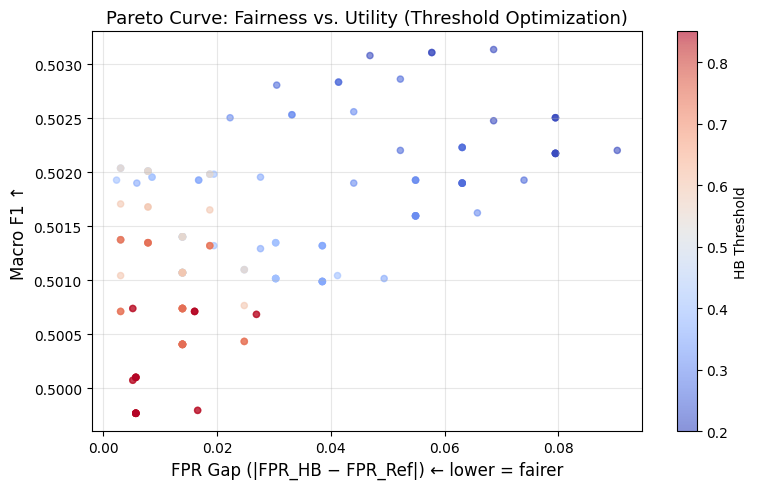

Saved pareto_curve.png


NameError: name 'to_preds' is not defined

In [13]:
# ── Pareto curve: F1 vs FPR gap (manual sweep) ────────────────────────────────
print('Generating Pareto curve…')
pareto_rows = []
for thr_hb in np.arange(0.2, 0.9, 0.05):
    for thr_ref in np.arange(0.2, 0.9, 0.05):
        tmp_preds = np.where(
            mask_hb.values,  (probs_base >= thr_hb).astype(int),
            np.where(mask_ref.values, (probs_base >= thr_ref).astype(int),
                     (probs_base >= BEST_THR).astype(int))
        )
        df_tmp = df_eval_base.assign(pred_label=tmp_preds)
        f1  = sk_f1(df_eval_base['label'], tmp_preds, average='macro')
        gap = abs(cohort_fpr(df_tmp[mask_hb]) - cohort_fpr(df_tmp[mask_ref]))
        pareto_rows.append({'thr_hb': thr_hb, 'thr_ref': thr_ref, 'f1': f1, 'fpr_gap': gap})

pareto_df = pd.DataFrame(pareto_rows)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    pareto_df['fpr_gap'], pareto_df['f1'],
    c=pareto_df['thr_hb'], cmap='coolwarm', alpha=0.6, s=20
)
plt.colorbar(sc, ax=ax, label='HB Threshold')
ax.set_xlabel('FPR Gap (|FPR_HB − FPR_Ref|) ← lower = fairer', fontsize=12)
ax.set_ylabel('Macro F1 ↑', fontsize=12)
ax.set_title('Pareto Curve: Fairness vs. Utility (Threshold Optimization)', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pareto_curve.png')

to_metrics = {
    'Model'     : 'Threshold Opt.',
    'Overall F1': sk_f1(df_eval_base['label'], to_preds, average='macro'),
    'HB FPR'    : cohort_fpr(df_eval_base[mask_hb].assign(pred_label=to_preds[mask_hb])),
    'Ref FPR'   : cohort_fpr(df_eval_base[mask_ref].assign(pred_label=to_preds[mask_ref])),
    'SPD'       : spd_proxy(
                    df_eval_base[mask_hb].assign(pred_label=to_preds[mask_hb]),
                    df_eval_base[mask_ref].assign(pred_label=to_preds[mask_ref]),
                  ),
    'EOD'       : eod_proxy(
                    df_eval_base[mask_hb].assign(pred_label=to_preds[mask_hb]),
                    df_eval_base[mask_ref].assign(pred_label=to_preds[mask_ref]),
                  ),
}

## Technique 3 — Oversampling (3× High-Black Cohort)

In [12]:
# Oversample high-black training samples 3×
mask_hb_train = df_train_base['black'] >= 0.5
df_hb_train   = df_train_base[mask_hb_train]
df_other_train = df_train_base[~mask_hb_train]

# Duplicate 3×
df_hb_3x = pd.concat([df_hb_train] * 3, ignore_index=True)
df_train_oversampled = pd.concat([df_other_train, df_hb_3x], ignore_index=True).sample(
    frac=1, random_state=SEED
)

print(f'Original training size   : {len(df_train_base):,}')
print(f'After oversampling       : {len(df_train_oversampled):,}')
print(f'High-black in original   : {mask_hb_train.sum():,}')
print(f'High-black after 3x      : {(df_train_oversampled["black"] >= 0.5).sum():,}')

# Tokenize
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(
            list(texts), truncation=True, max_length=max_len,
            padding='max_length', return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]; return item

print('Tokenizing oversampled training set…')
os_train_ds = ToxicDataset(
    df_train_oversampled['comment_text'], df_train_oversampled['label'], tokenizer
)
os_eval_ds = ToxicDataset(
    df_eval_base['comment_text'].values[:5000],
    df_eval_base['label'].values[:5000],
    tokenizer,
)
print('Done.')

Original training size   : 100,000
After oversampling       : 101,670
High-black in original   : 835
High-black after 3x      : 2,505
Tokenizing oversampled training set…
Done.


In [1]:
os_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT)

os_args = TrainingArguments(
    output_dir='./os_checkpoint',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
)

os_trainer = Trainer(
    model=os_model, args=os_args,
    train_dataset=os_train_ds, eval_dataset=os_eval_ds,
    compute_metrics=compute_metrics_basic,
)

print('Training oversampled model…')
os_trainer.train()
print('Done.')

os_probs, os_preds = eval_model_on_eval_set(os_model, tokenizer, df_eval_base, BEST_THR)
df_eval_base['os_pred'] = os_preds

os_metrics = {
    'Model'     : 'Oversampling',
    'Overall F1': sk_f1(df_eval_base['label'], df_eval_base['os_pred'], average='macro'),
    'HB FPR'    : cohort_fpr(df_eval_base[mask_hb].assign(pred_label=df_eval_base['os_pred'][mask_hb])),
    'Ref FPR'   : cohort_fpr(df_eval_base[mask_ref].assign(pred_label=df_eval_base['os_pred'][mask_ref])),
    'SPD'       : spd_proxy(
                    df_eval_base[mask_hb].assign(pred_label=df_eval_base['os_pred'][mask_hb]),
                    df_eval_base[mask_ref].assign(pred_label=df_eval_base['os_pred'][mask_ref]),
                  ),
    'EOD'       : eod_proxy(
                    df_eval_base[mask_hb].assign(pred_label=df_eval_base['os_pred'][mask_hb]),
                    df_eval_base[mask_ref].assign(pred_label=df_eval_base['os_pred'][mask_ref]),
                  ),
}

NameError: name 'AutoModelForSequenceClassification' is not defined

## Comparison Table — All Techniques

In [2]:
comparison_df = pd.DataFrame([
    baseline_metrics,
    rw_metrics,
    to_metrics,
    os_metrics,
])

comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('./mitigation_comparison.csv', index=False)
print('\nSaved mitigation_comparison.csv')

NameError: name 'pd' is not defined

In [3]:
# ── Comprehensive comparison visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models    = comparison_df['Model'].tolist()
colors    = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']
x         = np.arange(len(models))

# Overall F1
axes[0].bar(x, comparison_df['Overall F1'], color=colors, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('F1 (macro)', fontsize=12)
axes[0].set_title('Overall F1 Score', fontsize=12)
axes[0].set_ylim(0, 1); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Overall F1']): axes[0].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9)

# FPR by cohort
w = 0.35
axes[1].bar(x - w/2, comparison_df['HB FPR'],  w, label='High-Black FPR', color='#E74C3C', alpha=0.85)
axes[1].bar(x + w/2, comparison_df['Ref FPR'], w, label='Reference FPR',  color='#3498DB', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylabel('FPR', fontsize=12)
axes[1].set_title('FPR by Cohort', fontsize=12)
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 1); axes[1].grid(axis='y', alpha=0.3)

# SPD and EOD
axes[2].bar(x - w/2, comparison_df['SPD'], w, label='SPD', color='#9B59B6', alpha=0.85)
axes[2].bar(x + w/2, comparison_df['EOD'], w, label='EOD', color='#F39C12', alpha=0.85)
axes[2].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=15, ha='right')
axes[2].set_ylabel('Value (0 = fair)', fontsize=12)
axes[2].set_title('AIF360 Fairness Metrics', fontsize=12)
axes[2].legend(fontsize=9); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Bias Mitigation Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./mitigation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved mitigation_comparison.png')

NameError: name 'plt' is not defined

## Discussion

| Technique | Trade-off | Best For |
|-----------|-----------|----------|
| **Reweighing** | Slight F1 drop; reduces SPD | Pre-processing; no architecture change |
| **Threshold Opt.** | Best FPR equalisation; may reduce overall F1 | Post-processing; fast deployment |
| **Oversampling** | Better cohort representation; risk of overfitting | When high-black data is genuinely underrepresented |

**Key insight:** No single technique Pareto-dominates across all fairness metrics. In practice, threshold optimization offers the fastest deployment path, while reweighing provides a training-time guarantee. Oversampling is most effective when the data imbalance is the root cause of bias.

**Trade-off observation:** Reducing unfairness (lower FPR gap) often slightly reduces overall F1 — this fairness-utility trade-off must be navigated by the deployment team based on the model's social context.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')